# Practice 2: Transfer Learning with Pretrained Architectures on CIFAR-10

## ResNet18 vs DenseNet121 — Frozen vs Fine-tuned

Load CIFAR-10, adapt ImageNet-pretrained ResNet18 and DenseNet121 for 10-class classification, train both frozen-backbone (feature extraction) and fine-tuned variants, compare across a hyperparameter sweep (learning rate x batch size), monitor with TensorBoard.

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Data Preparation | CIFAR-10 download, split persistence, ImageNet-compatible transforms, DataLoaders | `src/data/load_cifar10` |
| 3 | Model Architecture | Load pretrained ResNet18/DenseNet121, replace final layer, freeze/unfreeze | `torchvision.models` |
| 4 | Train Models | Training loop, hyperparameter sweep (LR x batch size), TensorBoard logging | `src/training/` |
| 5 | Evaluate | Test-set accuracy, confusion matrices, per-class metrics | `src/eval/` |
| 6 | Compare & Report | Side-by-side comparison across all runs, summary table | — |
| 7 | Save Models | Save best checkpoints | — |

---


## Notebook Workflow

```mermaid
flowchart TD
    A["1. Import Libraries &amp; Detect Device"] --> B["2. Data Preparation \n(CIFAR-10 + Transforms)"]
    B --> C["3. Model Architecture \n(Pretrained ResNet18 / DenseNet121)"]
    C --> D["4. Train Models \n(Frozen vs Fine-tuned, LR x BS sweep)"]
    D --> E["5. Evaluate \n(Test accuracy, per-class metrics)"]
    E --> F["6. Compare &amp; Report \n(Summary table across runs)"]
    F --> G["7. Save Models \n(Best checkpoints)"]

    subgraph Data["Data Pipeline"]
        B1["CIFAR-10 32x32"] --> B2["Resize(224) + Augment"]
        B2 --> B3["ImageNet Normalize"]
        B3 --> B4["train/val/test DataLoaders"]
    end

    subgraph Models["Architectures"]
        C1["ResNet18 \n(pretrained on ImageNet)"] --- C2["DenseNet121 \n(pretrained on ImageNet)"]
    end
```


## 1. Import Libraries

Set up environment, detect available device (MPS / CUDA / CPU), import project modules.


In [10]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))

import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from src.data.load_cifar10 import (
    get_cifar10_loaders,
    SPLIT_FILE,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

# Device detection
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Using device: {device}")


PyTorch version: 2.13.0+cu130
Torchvision version: 0.28.0+cu130
Using device: cuda


## 2. Data Preparation — CIFAR-10

CIFAR-10: 10 classes, 32x32 RGB images, 50k train / 10k test. Pretrained models expect **224x224 ImageNet-normalized** input, so the transform pipeline resizes and normalizes accordingly.

**Transform pipeline (train):** `Resize(224)` -> `RandomHorizontalFlip()` -> `RandomCrop(224, padding=16)` -> `ToTensor()` -> `Normalize(ImageNet stats)`

**Train/val split:** 45k / 5k, generated once with `seed=42` and persisted to `data/processed/cifar10_split_seed42.json`. All phases share the same split.

**Batch size:** 64 (default, sweep later).  **num_workers:** 2.


Train: 45000  |  Val: 5000  |  Test: 10000
Split file: C:\document\Study documents\Deeplearning_Course\data\processed\cifar10_split_seed42.json


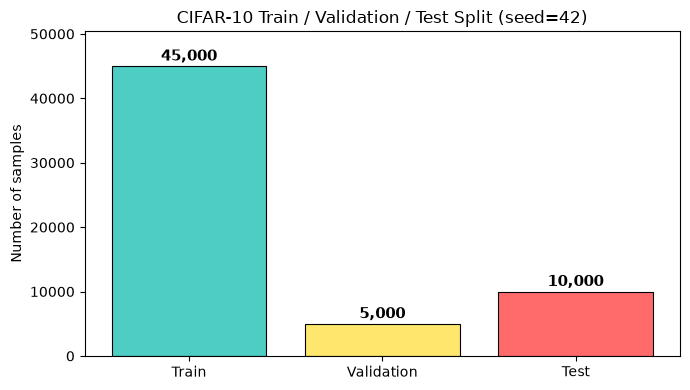

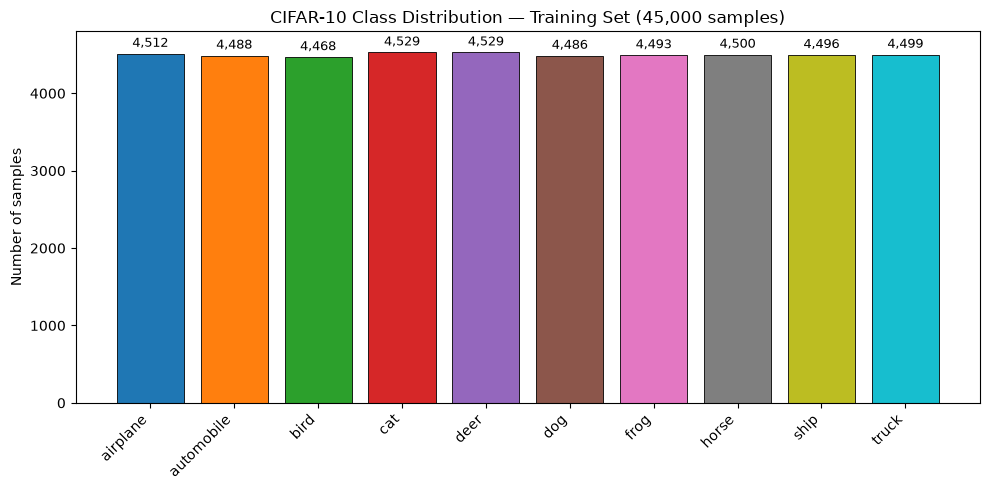


Batch shape: torch.Size([64, 3, 224, 224])  (batch, channels, H, W)
Pixel range after ImageNet normalization: -2.118 to 2.640
No NaN values: True


In [11]:
train_loader, val_loader, test_loader = get_cifar10_loaders(
    batch_size=64, num_workers=2
)

# ---- Split sizes ----
with open(SPLIT_FILE) as f:
    split = json.load(f)

n_train = len(split["train_indices"])
n_val   = len(split["val_indices"])
n_test  = len(split["test_indices"])

print(f"Train: {n_train}  |  Val: {n_val}  |  Test: {n_test}")
print(f"Split file: {SPLIT_FILE}")

# ---- Train/val/test distribution bar plot ----
fig, ax = plt.subplots(figsize=(7, 4))
splits = ["Train", "Validation", "Test"]
counts = [n_train, n_val, n_test]
colors = ["#4ECDC4", "#FFE66D", "#FF6B6B"]
bars = ax.bar(splits, counts, color=colors, edgecolor="black", linewidth=0.8)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{count:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of samples")
ax.set_title("CIFAR-10 Train / Validation / Test Split (seed=42)")
ax.set_ylim(0, max(counts) * 1.12)
plt.tight_layout()
plt.show()

# ---- Class distribution in the train set ----
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# Count labels efficiently by iterating train indices
raw_train = torchvision.datasets.CIFAR10(
    root="../data/raw", train=True, transform=None, download=False
)
label_counter = Counter(
    raw_train[idx][1] for idx in split["train_indices"]
)

fig, ax = plt.subplots(figsize=(10, 5))
class_ids = range(10)
class_counts = [label_counter[i] for i in class_ids]
bar_colors = plt.cm.tab10(np.linspace(0, 1, 10))
bars = ax.bar(CIFAR10_CLASSES, class_counts, color=bar_colors,
              edgecolor="black", linewidth=0.6)
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{count:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Number of samples")
ax.set_title("CIFAR-10 Class Distribution — Training Set (45,000 samples)")
ax.set_ylim(0, max(class_counts) * 1.06)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---- Quick shape sanity check ----
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}  (batch, channels, H, W)")
print(f"Pixel range after ImageNet normalization: "
      f"{images.min().item():.3f} to {images.max().item():.3f}")
print(f"No NaN values: {not torch.isnan(images).any()}")


## 3. Model Architecture

Load ImageNet-pretrained **ResNet18** and **DenseNet121** from torchvision, replace the final classification layer for 10 CIFAR-10 classes, and configure two freeze strategies per architecture:
- **Frozen (feature extraction):** only the new final layer is trainable
- **Fine-tune:** the last residual/dense block + final layer are trainable

The `weights=ResNet18_Weights.DEFAULT` API is used (torchvision 0.28.0, `pretrained=True` is deprecated).


In [12]:
from src.models.build_model import (
    build_resnet18, build_densenet121,
    count_trainable_params, count_all_params,
)

# --- Build all four variants ---
rn_frozen  = build_resnet18(num_classes=10, mode="frozen")
rn_finetune = build_resnet18(num_classes=10, mode="finetune")
dn_frozen  = build_densenet121(num_classes=10, mode="frozen")
dn_finetune = build_densenet121(num_classes=10, mode="finetune")

models_info = [
    ("ResNet18 (frozen)", rn_frozen, "fc(512, 10)"),
    ("ResNet18 (finetune)", rn_finetune, "fc(512, 10) + layer4"),
    ("DenseNet121 (frozen)", dn_frozen, "classifier(1024, 10)"),
    ("DenseNet121 (finetune)", dn_finetune, "classifier(1024, 10) + denseblock4"),
]

print(f"{"Model":30s} {"Trainable":>10s} {"Total":>10s}  Trainable layers")
print(f"{"-"*30} {"-"*10} {"-"*10}  {"-"*25}")
for name, model, layers in models_info:
    t = count_trainable_params(model)
    a = count_all_params(model)
    print(f"{name:30s} {t:>10,} {a:>10,}  {layers}")


Model                           Trainable      Total  Trainable layers
------------------------------ ---------- ----------  -------------------------
ResNet18 (frozen)                   5,130 11,181,642  fc(512, 10)
ResNet18 (finetune)             8,398,858 11,181,642  fc(512, 10) + layer4
DenseNet121 (frozen)               10,250  6,964,106  classifier(1024, 10)
DenseNet121 (finetune)          2,170,378  6,964,106  classifier(1024, 10) + denseblock4


### 3.1 Forward pass sanity check

Verify all four variants produce `(batch, 10)` output.


In [13]:
dummy = torch.randn(4, 3, 224, 224)
for name, model, _ in models_info:
    model.eval()
    with torch.no_grad():
        out = model(dummy)
    print(f"  {name:30s} -> {out.shape}")
print("\u2713 All models pass forward check.")


  ResNet18 (frozen)              -> torch.Size([4, 10])
  ResNet18 (finetune)            -> torch.Size([4, 10])
  DenseNet121 (frozen)           -> torch.Size([4, 10])
  DenseNet121 (finetune)         -> torch.Size([4, 10])
✓ All models pass forward check.


## 4. Train Models

*To be implemented.*


In [14]:
# TODO: Phase 3 - training_info.md


## 5. Evaluate

*To be implemented.*


In [15]:
# TODO: Phase 4 - eval.md


## 6. Compare & Report

*To be implemented.*


In [16]:
# TODO: Summary table across all runs


## 7. Save Models

*To be implemented.*


In [17]:
# TODO: Save best checkpoints
